# TP2 — DMRG

Two-site DMRG from scratch on the Heisenberg chain, then the Hubbard chain with TeNPy.

## 1. Heisenberg chain, from scratch

The Heisenberg model on a chain with open boundary conditions is given by Hamiltonian $H = J\sum_{i=1}^{L-1} \vec S_i\cdot\vec S_{i+1}$. We will look for the ground state in $S^z_{\rm tot}=0$ sector. This should correspond to the half-filled, $S^z=0$ Hubbard chain under $H_{\rm eff}=\frac{4t^2}{U}\sum_i(\vec S_i\cdot\vec S_{i+1}-\tfrac14)$.

As an MPO, $H = W^{[1]} W^{[2]} \cdots W^{[L]}$, the matrix products taken with $\otimes$ between the operator entries. In the bulk, $1 < i < L$, with $S^\pm = S^x \pm i S^y$ and the row index $w_L$, column index $w_R$ running over $D=5$ values,

$$
W^{[i]} = \begin{pmatrix}
I & S^+ & S^- & S^z & 0 \\
0 & 0 & 0 & 0 & \tfrac{J}{2}\,S^- \\
0 & 0 & 0 & 0 & \tfrac{J}{2}\,S^+ \\
0 & 0 & 0 & 0 & J\,S^z \\
0 & 0 & 0 & 0 & I
\end{pmatrix}.
$$

At the ends only the first row and the last column survive, so that the chain closes on a scalar:

$$
W^{[1]} = \begin{pmatrix} I & S^+ & S^- & S^z & 0 \end{pmatrix},
\qquad
W^{[L]} = \begin{pmatrix} 0 \\ \tfrac{J}{2}\,S^- \\ \tfrac{J}{2}\,S^+ \\ J\,S^z \\ I \end{pmatrix}.
$$

Implemented in `HeisenbergModel.init_H_mpo` below — note that the code keeps the *full* $D \times D$ tensor on every site, ends included. The reduction to the first row and the last column is instead performed by `SimpleDMRGEngine.__init__`, which seeds the environments as `LP[:, 0, :] = np.eye(chi)` and `RP[:, D-1, :] = np.eye(chi)`.

In [1]:
# Toy codes adapted minimally from https://tenpy.readthedocs.io/en/latest/toycode_stubs/
# a_mps.py and d_dmrg.py, verbatim; b_model.TFIModel replaced by HeisenbergModel below.

import warnings

import numpy as np
from scipy.linalg import svd
import scipy.sparse
from scipy.sparse.linalg import eigsh


class SimpleMPS:
    """Simple class for a matrix product state.

    We index sites with `i` from 0 to L-1; bond `i` is left of site `i`.
    We *assume* that the state is in right-canonical form.

    Parameters
    ----------
    Bs, Ss, bc:
        Same as attributes.

    Attributes
    ----------
    Bs : list of np.Array[ndim=3]
        The 'matrices', in right-canonical form, one for each physical site
        (within the unit-cell for an infinite MPS).
        Each `B[i]` has legs (virtual left, physical, virtual right), in short ``vL i vR``.
    Ss : list of np.Array[ndim=1]
        The Schmidt values at each of the bonds, ``Ss[i]`` is left of ``Bs[i]``.
    bc : 'infinite', 'finite'
        Boundary conditions.
    L : int
        Number of sites (in the unit-cell for an infinite MPS).
    nbonds : int
        Number of (non-trivial) bonds: L-1 for 'finite' boundary conditions, L for 'infinite'.
    """
    def __init__(self, Bs, Ss, bc='finite'):
        assert bc in ['finite', 'infinite']
        self.Bs = Bs
        self.Ss = Ss
        self.bc = bc
        self.L = len(Bs)
        self.nbonds = self.L - 1 if self.bc == 'finite' else self.L

    def copy(self):
        return SimpleMPS([B.copy() for B in self.Bs], [S.copy() for S in self.Ss], self.bc)

    def get_theta1(self, i):
        """Calculate effective single-site wave function on sites i in mixed canonical form.

        The returned array has legs ``vL, i, vR`` (as one of the Bs).
        """
        return np.tensordot(np.diag(self.Ss[i]), self.Bs[i], [1, 0])  # vL [vL'], [vL] i vR

    def get_theta2(self, i):
        """Calculate effective two-site wave function on sites i,j=(i+1) in mixed canonical form.

        The returned array has legs ``vL, i, j, vR``.
        """
        j = (i + 1) % self.L
        return np.tensordot(self.get_theta1(i), self.Bs[j], [2, 0])  # vL i [vR], [vL] j vR

    def get_chi(self):
        """Return bond dimensions."""
        return [self.Bs[i].shape[2] for i in range(self.nbonds)]

    def site_expectation_value(self, op):
        """Calculate expectation values of a local operator at each site."""
        result = []
        for i in range(self.L):
            theta = self.get_theta1(i)  # vL i vR
            op_theta = np.tensordot(op, theta, axes=(1, 1))  # i [i*], vL [i] vR
            result.append(np.tensordot(theta.conj(), op_theta, [[0, 1, 2], [1, 0, 2]]))
            # [vL*] [i*] [vR*], [i] [vL] [vR]
        return np.real_if_close(result)

    def bond_expectation_value(self, op):
        """Calculate expectation values of a local operator at each bond."""
        result = []
        for i in range(self.nbonds):
            theta = self.get_theta2(i)  # vL i j vR
            op_theta = np.tensordot(op[i], theta, axes=([2, 3], [1, 2]))
            # i j [i*] [j*], vL [i] [j] vR
            result.append(np.tensordot(theta.conj(), op_theta, [[0, 1, 2, 3], [2, 0, 1, 3]]))
            # [vL*] [i*] [j*] [vR*], [i] [j] [vL] [vR]
        return np.real_if_close(result)

    def entanglement_entropy(self):
        """Return the (von-Neumann) entanglement entropy for a bipartition at any of the bonds."""
        bonds = range(1, self.L) if self.bc == 'finite' else range(0, self.L)
        result = []
        for i in bonds:
            S = self.Ss[i]
            S = S[S > 1.e-20]  # 0*log(0) should give 0 and won't contribute to the sum
            # avoid warning or NaN by discarding the very small values of S
            S2 = S * S
            assert abs(np.linalg.norm(S) - 1.) < 1.e-13
            result.append(-np.sum(S2 * np.log(S2)))
        return np.array(result)

    def correlation_length(self):
        """Diagonalize transfer matrix to obtain the correlation length."""
        from scipy.sparse.linalg import eigs
        if self.get_chi()[0] > 100:
            warnings.warn("Skip calculating correlation_length() for large chi: could take long")
            return -1.
        assert self.bc == 'infinite'  # works only in the infinite case
        B = self.Bs[0]  # vL i vR
        chi = B.shape[0]
        T = np.tensordot(B, np.conj(B), axes=(1, 1))  # vL [i] vR, vL* [i*] vR*
        T = np.transpose(T, [0, 2, 1, 3])  # vL vL* vR vR*
        for i in range(1, self.L):
            B = self.Bs[i]
            T = np.tensordot(T, B, axes=(2, 0))  # vL vL* [vR] vR*, [vL] i vR
            T = np.tensordot(T, np.conj(B), axes=([2, 3], [0, 1]))
            # vL vL* [vR*] [i] vR, [vL*] [i*] vR*
        T = np.reshape(T, (chi**2, chi**2))
        # Obtain the 2nd largest eigenvalue
        eta = eigs(T, k=2, which='LM', return_eigenvectors=False, ncv=20)
        xi =  -self.L / np.log(np.min(np.abs(eta)))
        if xi > 1000.:
            return np.inf
        return xi

    def correlation_function(self, op_i, i, op_j, j):
        """Correlation function between two distant operators on sites i < j.

        Note: calling this function in a loop over `j` is inefficient for large j >> i.
        The optimization is left as an exercise to the user.
        Hint: Re-use the partial contractions up to but excluding site `j`.
        """
        assert i < j
        theta = self.get_theta1(i) # vL i vR
        C = np.tensordot(op_i, theta, axes=(1, 1)) # i [i*], vL [i] vR
        C = np.tensordot(theta.conj(), C, axes=([0, 1], [1, 0]))  # [vL*] [i*] vR*, [i] [vL] vR
        for k in range(i + 1, j):
            k = k % self.L
            B = self.Bs[k]  # vL k vR
            C = np.tensordot(C, B, axes=(1, 0)) # vR* [vR], [vL] k vR
            C = np.tensordot(B.conj(), C, axes=([0, 1], [0, 1])) # [vL*] [k*] vR*, [vR*] [k] vR
        j = j % self.L
        B = self.Bs[j]  # vL k vR
        C = np.tensordot(C, B, axes=(1, 0)) # vR* [vR], [vL] j vR
        C = np.tensordot(op_j, C, axes=(1, 1))  # j [j*], vR* [j] vR
        C = np.tensordot(B.conj(), C, axes=([0, 1, 2], [1, 0, 2])) # [vL*] [j*] [vR*], [j] [vR*] [vR]
        return C


def init_FM_MPS(L, d=2, bc='finite'):
    """Return a ferromagnetic MPS (= product state with all spins up)"""
    B = np.zeros([1, d, 1], dtype=float)
    B[0, 0, 0] = 1.
    S = np.ones([1], dtype=float)
    Bs = [B.copy() for i in range(L)]
    Ss = [S.copy() for i in range(L)]
    return SimpleMPS(Bs, Ss, bc=bc)


def init_Neel_MPS(L, d=2, bc='finite'):
    """Return a Neel state MPS (= product state with alternating spins up  down up down... )"""
    S = np.ones([1], dtype=float)
    Bs = []
    for i in range(L):
        B = np.zeros([1, d, 1], dtype=float)
        if i % 2 == 0:
            B[0, 0, 0] = 1.
        else:
            B[0, -1, 0] = 1.
        Bs.append(B)
    Ss = [S.copy() for i in range(L)]
    return SimpleMPS(Bs, Ss, bc=bc)


def split_truncate_theta(theta, chi_max, eps):
    """Split and truncate a two-site wave function in mixed canonical form.

    Split a two-site wave function as follows::
          vL --(theta)-- vR     =>    vL --(A)--diag(S)--(B)-- vR
                |   |                       |             |
                i   j                       i             j

    Afterwards, truncate in the new leg (labeled ``vC``).

    Parameters
    ----------
    theta : np.Array[ndim=4]
        Two-site wave function in mixed canonical form, with legs ``vL, i, j, vR``.
    chi_max : int
        Maximum number of singular values to keep
    eps : float
        Discard any singular values smaller than that.

    Returns
    -------
    A : np.Array[ndim=3]
        Left-canonical matrix on site i, with legs ``vL, i, vC``
    S : np.Array[ndim=1]
        Singular/Schmidt values.
    B : np.Array[ndim=3]
        Right-canonical matrix on site j, with legs ``vC, j, vR``
    """
    chivL, dL, dR, chivR = theta.shape
    theta = np.reshape(theta, [chivL * dL, dR * chivR])
    X, Y, Z = svd(theta, full_matrices=False)
    # truncate
    chivC = min(chi_max, np.sum(Y > eps))
    assert chivC >= 1
    piv = np.argsort(Y)[::-1][:chivC]  # keep the largest `chivC` singular values
    X, Y, Z = X[:, piv], Y[piv], Z[piv, :]
    # renormalize
    S = Y / np.linalg.norm(Y)  # == Y/sqrt(sum(Y**2))
    # split legs of X and Z
    A = np.reshape(X, [chivL, dL, chivC])
    B = np.reshape(Z, [chivC, dR, chivR])
    return A, S, B


class HeisenbergModel:
    r"""Simple class generating the Hamiltonian of the spin-1/2 Heisenberg model.

    The Hamiltonian reads
    .. math ::
        H = J \sum_{i} \vec{S}_i \cdot \vec{S}_{i+1}

    Parameters
    ----------
    L : int
        Number of sites.
    J : float
        Coupling parameter of the above defined Hamiltonian.
    bc : 'infinite', 'finite'
        Boundary conditions.

    Attributes
    ----------
    L : int
        Number of sites.
    bc : 'infinite', 'finite'
        Boundary conditions.
    Sz, Sp, Sm, id :
        Local operators, namely the spin-1/2 operators and identity.
    H_bonds : list of np.Array[ndim=4]
        The Hamiltonian written in terms of local 2-site operators, ``H = sum_i H_bonds[i]``.
        Each ``H_bonds[i]`` has (physical) legs (i out, (i+1) out, i in, (i+1) in),
        in short ``i j i* j*``.
    H_mpo : lit of np.Array[ndim=4]
        The Hamiltonian written as an MPO.
        Each ``H_mpo[i]`` has legs (virtual left, virtual right, physical out, physical in),
        in short ``wL wR i i*``.
    """
    def __init__(self, L, J=1., bc='finite'):
        assert bc in ['finite', 'infinite']
        self.L, self.d, self.bc = L, 2, bc
        self.J = J
        self.Sz = np.array([[0.5, 0.], [0., -0.5]])
        self.Sp = np.array([[0., 1.], [0., 0.]])
        self.Sm = np.array([[0., 0.], [1., 0.]])
        self.id = np.eye(2)
        self.init_H_bonds()
        self.init_H_mpo()

    def init_H_bonds(self):
        """Initialize `H_bonds` hamiltonian.

        Called by __init__().
        """
        Sz, Sp, Sm = self.Sz, self.Sp, self.Sm
        d = self.d
        nbonds = self.L - 1 if self.bc == 'finite' else self.L
        H_list = []
        for i in range(nbonds):
            H_bond = self.J * (np.kron(Sz, Sz) + 0.5 * (np.kron(Sp, Sm) + np.kron(Sm, Sp)))
            # note: kron is short-hand for outer product + grouping bra and ket legs.
            # H_bond has legs ``i, j, i*, j*``
            H_list.append(np.reshape(H_bond, [d, d, d, d]))
        self.H_bonds = H_list

    def init_H_mpo(self):
        """Initialize `H_mpo` Hamiltonian.

        Called by __init__().
        """
        w_list = []
        for i in range(self.L):
            w = np.zeros((5, 5, self.d, self.d), dtype=float)
            w[0, 0] = w[4, 4] = self.id
            w[0, 1] = self.Sp
            w[0, 2] = self.Sm
            w[0, 3] = self.Sz
            w[1, 4] = 0.5 * self.J * self.Sm
            w[2, 4] = 0.5 * self.J * self.Sp
            w[3, 4] = self.J * self.Sz
            w_list.append(w)
        self.H_mpo = w_list


class SimpleDMRGEngine:
    """DMRG algorithm, implemented as class holding the necessary data.

    DMRG sweeps left-right-left through the system, moving the orthogonality center along.
    Here, we still just save right-canonical `B` tensors in `psi`, which requires taking inverses
    of the Schmidt values - this is bad practice, but it keeps two things simpler:
    - We don't need book keeping in the MPS class to keep track of the canonical form, and all the
    MPS methods (expectation values etc) can just *assume* that the MPS is in right-canonical form.
    - The generalization to the infinite case is straight forward.
    Note, however, that we only use the A and B tensors directly from the SVD (without taking
    inverses) to update the environments. The effective Hamiltonian does thus not suffer
    from taking the inverses of Schmidt values.

    Parameters
    ----------
    psi, model, chi_max, eps:
        See attributes

    Attributes
    ----------
    psi : SimpleMPS
        The current ground-state (approximation).
    model :
        The model of which the groundstate is to be calculated. Needs to have an `H_mpo`.
    chi_max, eps:
        Truncation parameters, see :func:`a_mps.split_truncate_theta`.
    LPs, RPs : list of np.Array[ndim=3]
        Left and right parts ("environments") of the effective Hamiltonian.
        ``LPs[i]`` is the contraction of all parts left of site `i` in the network ``<psi|H|psi>``,
        and similar ``RPs[i]`` for all parts right of site `i`.
        Each ``LPs[i]`` has legs ``vL wL* vL*``, ``RPs[i]`` has legs ``vR* wR* vR``
    """
    def __init__(self, psi, model, chi_max, eps):
        assert psi.L == model.L and psi.bc == model.bc  # ensure compatibility
        self.H_mpo = model.H_mpo
        self.psi = psi
        self.LPs = [None] * psi.L
        self.RPs = [None] * psi.L
        self.chi_max = chi_max
        self.eps = eps
        # initialize left and right environment
        D = self.H_mpo[0].shape[0]
        chi = psi.Bs[0].shape[0]
        LP = np.zeros([chi, D, chi], dtype=float)  # vL wL* vL*
        RP = np.zeros([chi, D, chi], dtype=float)  # vR* wR* vR
        LP[:, 0, :] = np.eye(chi)
        RP[:, D - 1, :] = np.eye(chi)
        self.LPs[0] = LP
        self.RPs[-1] = RP
        # initialize necessary RPs
        for i in range(psi.L - 1, 1, -1):
            self.update_RP(i, psi.Bs[i])

    def sweep(self):
        # sweep from left to right
        for i in range(self.psi.nbonds - 1):
            self.update_bond(i)
        # sweep from right to left
        for i in range(self.psi.nbonds - 1, 0, -1):
            E0 = self.update_bond(i)
        return E0

    def update_bond(self, i):
        j = (i + 1) % self.psi.L
        # get effective Hamiltonian
        Heff = SimpleHeff2(self.LPs[i], self.RPs[j], self.H_mpo[i], self.H_mpo[j])
        # Diagonalize Heff, find ground state `theta`
        theta_guess = self.psi.get_theta2(i)
        E0, theta = self.diag(Heff, theta_guess)
        # split and truncate
        Ai, Sj, Bj = split_truncate_theta(theta, self.chi_max, self.eps)
        # put back into MPS
        Gi = np.tensordot(np.diag(self.psi.Ss[i]**(-1)), Ai, axes=(1, 0))  # vL [vL*], [vL] i vC
        self.psi.Bs[i] = np.tensordot(Gi, np.diag(Sj), axes=(2, 0))  # vL i [vC], [vC*] vC
        self.psi.Ss[j] = Sj  # vC
        self.psi.Bs[j] = Bj  # vC j vR
        self.update_LP(i, Ai)
        self.update_RP(j, Bj)
        return E0

    def diag(self, Heff, guess):
        """Diagonalize the effective hamiltonian with an initial guess."""
        guess = np.reshape(guess, [Heff.shape[1]])
        E, V = eigsh(Heff, k=1, which='SA', return_eigenvectors=True, v0=guess)
        return E, np.reshape(V[:, 0], Heff.theta_shape)
        #  # alternatively, use custom lanczos implementation
        #  from .lanczos import lanczos_ground_state
        #  return lanczos_ground_state(H, guess)

    def update_RP(self, i, B):
        """Calculate RP environment right of site `i-1`.

        Uses RP right of `i` and the given, right-canonical `B` on site `i`."""
        j = (i - 1) % self.psi.L
        RP = self.RPs[i]  # vR* wR* vR
        # B has legs     vL i vR
        Bc = B.conj()  # vL* i* vR*
        W = self.H_mpo[i]  # wL wR i i*
        RP = np.tensordot(B, RP, axes=(2, 0))  # vL i [vR], [vR*] wR* vR
        RP = np.tensordot(RP, W, axes=([1, 2], [3, 1]))  # vL [i] [wR*] vR, wL [wR] i [i*]
        RP = np.tensordot(RP, Bc, axes=([1, 3], [2, 1]))  # vL [vR] wL [i], vL* [i*] [vR*]
        self.RPs[j] = RP  # vL wL vL* (== vR* wR* vR on site i-1)

    def update_LP(self, i, A):
        """Calculate LP environment left of site `i+1`.

        Uses the LP left of site `i` and the given, left-canonical `A` on site `i`."""
        j = (i + 1) % self.psi.L
        LP = self.LPs[i]  # vL wL vL*
        # A has legs    vL i vR
        Ac = A.conj()  # vL* i* vR*
        W = self.H_mpo[i]  # wL wR i i*
        LP = np.tensordot(LP, A, axes=(2, 0))  # vL wL* [vL*], [vL] i vR
        LP = np.tensordot(W, LP, axes=([0, 3], [1, 2]))  # [wL] wR i [i*], vL [wL*] [i] vR
        LP = np.tensordot(Ac, LP, axes=([0, 1], [2, 1]))  # [vL*] [i*] vR*, wR [i] [vL] vR
        self.LPs[j] = LP  # vR* wR vR (== vL wL* vL* on site i+1)


class SimpleHeff2(scipy.sparse.linalg.LinearOperator):
    """Class for the effective Hamiltonian on two sites.

    To be diagonalized in `SimpleDMRGEnginge.diag` during the bond update. Looks like this::

        .--vL*           vR*--.
        |       i*    j*      |
        |       |     |       |
       (LP)----(W1)--(W2)----(RP)
        |       |     |       |
        |       i     j       |
        .--vL             vR--.
    """
    def __init__(self, LP, RP, W1, W2):
        self.LP = LP  # vL wL* vL*
        self.RP = RP  # vR* wR* vR
        self.W1 = W1  # wL wC i i*
        self.W2 = W2  # wC wR j j*
        chi1, chi2 = LP.shape[0], RP.shape[2]
        d1, d2 = W1.shape[2], W2.shape[2]
        self.theta_shape = (chi1, d1, d2, chi2)  # vL i j vR
        self.shape = (chi1 * d1 * d2 * chi2, chi1 * d1 * d2 * chi2)
        self.dtype = W1.dtype
        super().__init__(dtype=self.dtype, shape=self.shape)  # needed for scipy >= 1.15

    def _matvec(self, theta):
        """Calculate the matrix-vecotr product |theta'> = H_eff |theta>.

        This function is used by :func:`scipy.sparse.linalg.eigsh` to diagonalize
        the effective Hamiltonian with a Lanczos method, withouth generating the full matrix.
        """
        x = np.reshape(theta, self.theta_shape)  # vL i j vR
        x = np.tensordot(self.LP, x, axes=(2, 0))  # vL wL* [vL*], [vL] i j vR
        x = np.tensordot(x, self.W1, axes=([1, 2], [0, 3]))  # vL [wL*] [i] j vR, [wL] wC i [i*]
        x = np.tensordot(x, self.W2, axes=([3, 1], [0, 3]))  # vL [j] vR [wC] i, [wC] wR j [j*]
        x = np.tensordot(x, self.RP, axes=([1, 3], [0, 1]))  # vL [vR] i [wR] j, [vR*] [wR*] vR
        x = np.reshape(x, self.shape[0])
        return x

    def _adjoint(self):
        """Define self as hermitian."""
        return self

    def trace(self):
        """The trace of the operator.

        Only needed in e_tdvp.py in expm_multiply for scipy version > 1.9.0 to avoid warnings,
        but cheap to calculate anyways.
        """
        return np.inner(np.trace(self.LP, axis1=0, axis2=2),                  # [vL] wL* [vL*]
                        np.dot(np.trace(self.W1, axis1=2, axis2=3),           # wL wC [i] [i*]
                               np.dot(np.trace(self.W2, axis1=2, axis2=3),    # wC wR [j] [j*]
                                      np.trace(self.RP, axis1=0, axis2=2))))  # [vR*] wR* [vR]

L = 24:  E = -10.4537857604   E/L = -0.435574   chi = 64
sector:   sum_i <S^z_i> = -5.3e-13        (S^z_tot = 0)
compare:  E/L -> 1/4 - ln2 = -0.443147  as L -> infinity

L = 12:  DMRG -5.1420906328   ED -5.1420906328   |diff| = 1.2e-14


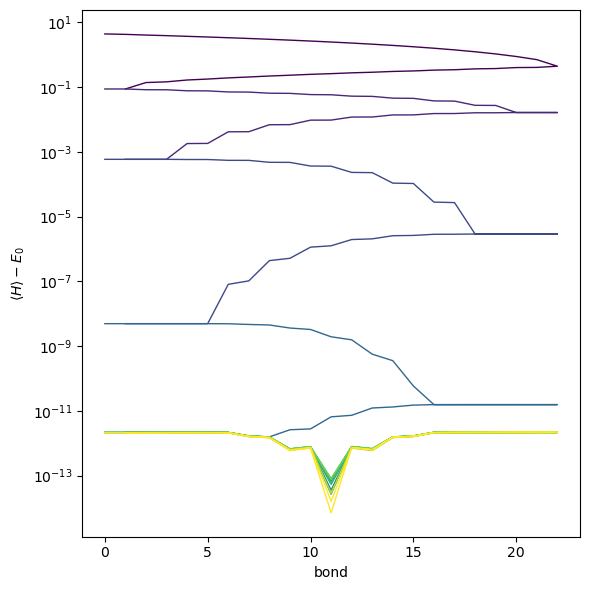

In [2]:
class RecordingDMRGEngine(SimpleDMRGEngine):
    """SimpleDMRGEngine that also records (bond, energy) at every local update."""
    def __init__(self, *args, **kwargs):
        self.history = []
        super().__init__(*args, **kwargs)

    def update_bond(self, i):
        E0 = super().update_bond(i)
        self.history.append((i, float(E0[0])))
        return E0


L, J, chi_max, n_sweeps = 24, 1.0, 64, 10

model = HeisenbergModel(L, J)
psi = init_Neel_MPS(L)
eng = RecordingDMRGEngine(psi, model, chi_max=chi_max, eps=1.e-10)
for _ in range(n_sweeps):
    eng.sweep()

E = np.sum(psi.bond_expectation_value(model.H_bonds))
Sz_tot = np.sum(psi.site_expectation_value(model.Sz))
print(f"L = {L}:  E = {E:.10f}   E/L = {E/L:.6f}   chi = {max(psi.get_chi())}")
print(f"sector:   sum_i <S^z_i> = {Sz_tot:+.1e}        (S^z_tot = 0)")
print(f"compare:  E/L -> 1/4 - ln2 = {0.25 - np.log(2):.6f}  as L -> infinity")

import matplotlib.pyplot as plt
bond, E_update = np.array(eng.history).T
per_sweep = 2 * (psi.nbonds - 1)
dE = E_update - E_update.min()

fig, ax1 = plt.subplots(1, 1, figsize=(6.0, 6.0) )
for s in range(n_sweeps):
    seg = slice(s * per_sweep, (s + 1) * per_sweep)
    col = plt.cm.viridis(s / (n_sweeps - 1))
    ax1.plot(bond[seg], np.where(dE[seg] > 0, dE[seg], np.nan), lw=1.0, color=col)
ax1.set_yscale('log')
ax1.set_xlabel("bond")
ax1.set_ylabel(r"$\langle H \rangle - E_0$")
fig.tight_layout()

def heisenberg_ed(L, J=1.):
    states = [s for s in range(1 << L) if bin(s).count('1') == L // 2]
    index = {s: i for i, s in enumerate(states)}
    H = np.zeros((len(states), len(states)))
    for a, s in enumerate(states):
        for i in range(L - 1):
            up_i, up_j = (s >> i) & 1, (s >> (i + 1)) & 1
            H[a, a] += J * (0.25 if up_i == up_j else -0.25)
            if up_i != up_j:
                H[index[s ^ (1 << i) ^ (1 << (i + 1))], a] += 0.5 * J

    return np.linalg.eigvalsh(H)[0]


Lc = 12
m_c, p_c = HeisenbergModel(Lc, J), init_Neel_MPS(Lc)
e_c = SimpleDMRGEngine(p_c, m_c, chi_max=64, eps=1.e-12)
for _ in range(12):
    e_c.sweep()
E_dmrg = np.sum(p_c.bond_expectation_value(m_c.H_bonds))
E_exact = heisenberg_ed(Lc, J)
print(f"\nL = {Lc}:  DMRG {E_dmrg:.10f}   ED {E_exact:.10f}   |diff| = {abs(E_dmrg-E_exact):.1e}")
E_heis_L = E

### Local observables

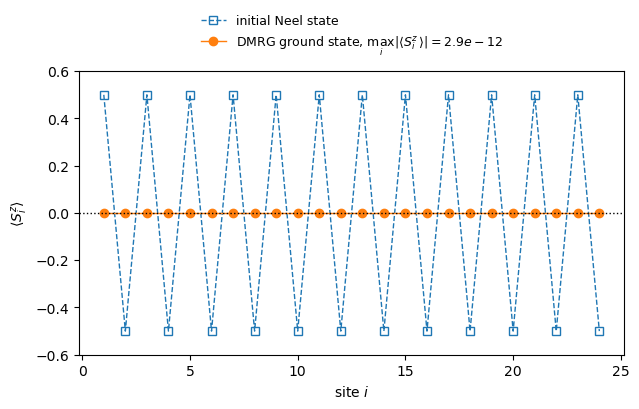

In [3]:
Sz_i = psi.site_expectation_value(model.Sz)
Sz_0 = init_Neel_MPS(L).site_expectation_value(model.Sz)   # the state DMRG started from
sites = np.arange(1, L + 1)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(sites, Sz_0, 's--', lw=1, mfc='none', label="initial Neel state")
ax.plot(sites, Sz_i, 'o-', lw=1,
        label=rf"DMRG ground state, $\max_i |\langle S^z_i\rangle| = {np.max(np.abs(Sz_i)):.1e}$")
ax.axhline(0., ls=':', lw=1, color='k')
ax.set_ylim(-0.6, 0.6)
ax.set_xlabel("site $i$")
ax.set_ylabel(r"$\langle S^z_i \rangle$")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), fontsize=9, frameon=False)
fig.tight_layout()

### Entanglement entropy

$$S(\ell) = \frac{c}{6}\,\ln\!\left[\frac{2L}{\pi}\sin\frac{\pi\ell}{L}\right] + s_1,$$

for a critical chain with open ends ($c/3$ for periodic ones); $c=1$ here. P. Calabrese and J. Cardy, *J. Stat. Mech.* (2004) P06002, [hep-th/0405152](https://arxiv.org/abs/hep-th/0405152). Fitted on even $\ell$ only.

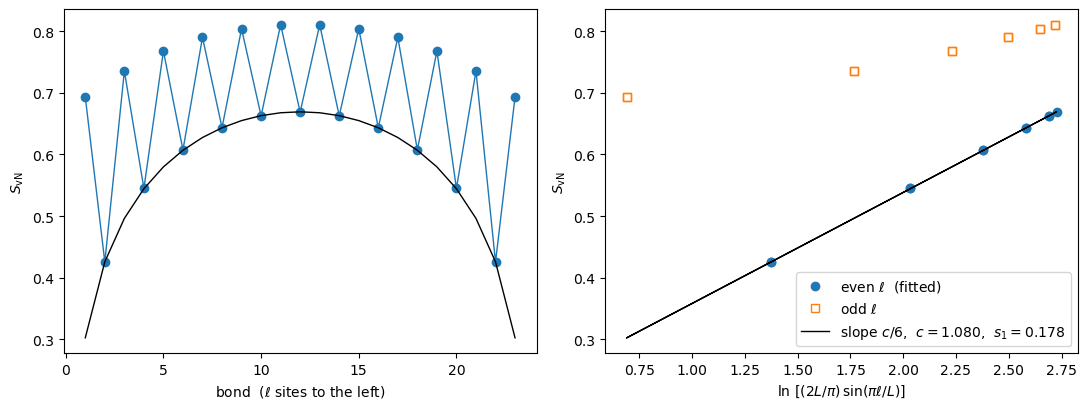

In [4]:
S_vN = psi.entanglement_entropy()
bonds = np.arange(1, L)

# Calabrese-Cardy, open chain:  S(l) = (c/6) ln[(2L/pi) sin(pi l/L)] + s1.
# Fit the even-l branch only: an odd block leaves an unpaired spin and sits on its own branch.
x = (2 * L / np.pi) * np.sin(np.pi * bonds / L)            # conformal chord length
even = bonds % 2 == 0
A = np.vstack([np.log(x[even]), np.ones(even.sum())]).T
(slope, s1), *_ = np.linalg.lstsq(A, S_vN[even], rcond=None)
c = 6 * slope

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.2))

ax.plot(bonds, S_vN, 'o-', lw=1)
ax.plot(bonds, (c / 6) * np.log(x) + s1, '-', color='k', lw=1)
ax.set_xlabel(r"bond  ($\ell$ sites to the left)")
ax.set_ylabel(r"$S_{\mathrm{vN}}$")

ax2.plot(np.log(x[even]), S_vN[even], 'o', label=r"even $\ell$  (fitted)")
ax2.plot(np.log(x[~even]), S_vN[~even], 's', mfc='none', label=r"odd $\ell$")
ax2.plot(np.log(x), (c / 6) * np.log(x) + s1, '-', color='k', lw=1,
         label=rf"slope $c/6$,  $c = {c:.3f}$,  $s_1 = {s1:.3f}$")
ax2.set_xlabel(r"$\ln\,[(2L/\pi)\,\sin(\pi\ell/L)]$")
ax2.set_ylabel(r"$S_{\mathrm{vN}}$")
ax2.legend()

fig.tight_layout()

## 2. Hubbard chain at half filling, with TeNPy

TeNPy conserves $N$ and $S^z$, so the sector is fixed by the initial product state. The cell below exemplifies how one can obtain the ground state in the sector Sz=0 at half filling.

In [5]:
from tenpy.models.hubbard import FermiHubbardChain
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg

t = 1.0
dmrg_params = {'mixer': True, 'combine': True, 'max_E_err': 1.e-10,
               'trunc_params': {'chi_max': 200, 'svd_min': 1.e-10}}


def hubbard_gs(L, U, p_state, t=1.0, chi_max=200):
    """Ground state in the sector fixed by the product state (TeNPy conserves N and S^z)."""
    M = FermiHubbardChain(dict(L=L, t=t, U=U, bc_MPS='finite',
                               cons_N='N', cons_Sz='Sz'))
    psi = MPS.from_product_state(M.lat.mps_sites(), p_state, bc='finite', unit_cell_width=L)
    pars = dict(dmrg_params, trunc_params=dict(dmrg_params['trunc_params'], chi_max=chi_max))
    return dmrg.run(psi, M, pars)['E'], psi


half_filling = ['up', 'down'] * (L // 2)          # N = L, S^z_tot = 0

print(f"half filling, L = {L}:   E_Hubbard   vs   (4t^2/U) (E_Heis - (L-1)/4)\n")
for U in (8., 16., 32.):
    E_hub, _ = hubbard_gs(L, U, half_filling, t)
    E_map = (4 * t**2 / U) * (E_heis_L - (L - 1) / 4)
    print(f"  U/t = {U:4.0f}   {E_hub:10.6f}   {E_map:10.6f}   "
          f"rel. dev. {abs(E_hub-E_map)/abs(E_map):6.2%}   (t/U)^2 = {1/U**2:.4f}")

half filling, L = 24:   E_Hubbard   vs   (4t^2/U) (E_Heis - (L-1)/4)

  U/t =    8    -7.655908    -8.101893   rel. dev.  5.50%   (t/U)^2 = 0.0156
  U/t =   16    -3.990782    -4.050946   rel. dev.  1.49%   (t/U)^2 = 0.0039
  U/t =   32    -2.017797    -2.025473   rel. dev.  0.38%   (t/U)^2 = 0.0010


As we move into the strong coupling limit, the energy of the Hubbard model approaches that of the Heisenberg chain (after a transformation).

### Question 1: Warm-up (Hubbard model versus Heisenberg model)
Plot the ground state energy of the Hubbard model at half filling in the $S_z=0$ sector, and the ground state energy of the corresponding Heisenberg model in the $S_z=0$ sector, versus $U/t$, for $t=1$ and the following values of $U$ `Us_E = np.array([4., 8., 16., 32., 64.])`. You may take $L=24$.

In [6]:
#### your implementation goes here.
from IPython.display import clear_output

t = 1.0
L = 12
dmrg_params = {'mixer': True, 'combine': True, 'max_E_err': 1.e-10,
               'trunc_params': {'chi_max': 50, 'svd_min': 1.e-7}}

half_filling = ['up', 'down'] * (L // 2)          # N = L, S^z_tot = 0

Us_E = np.array([4., 8., 16., 32., 64.])
E_hub = []
E_map = []
for U in Us_E:
    E_hub.append( hubbard_gs(L, U, half_filling, t)[0] )
    E_map.append ( (4 * t**2 / U) * (E_heis_L - (L - 1) / 4) )
    print(U)
#end
clear_output()

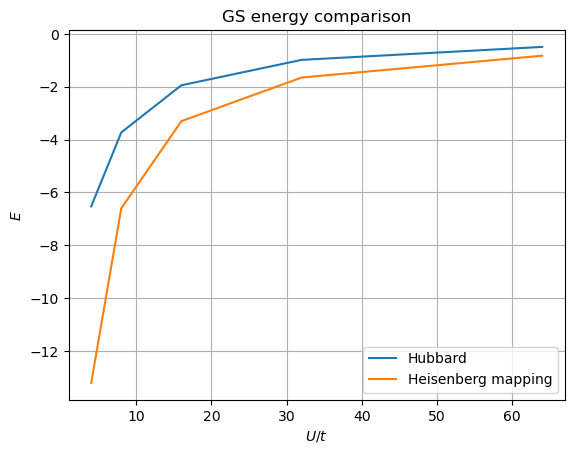

In [ ]:
plt.plot(Us_E, E_hub, label="Hubbard")
plt.plot(Us_E, E_map, label="Heisenberg mapping")
plt.title("GS energy comparison")
plt.grid()
plt.xlabel("$U/t$")
plt.ylabel("$E$")
plt.legend()

### Question 2: Comparison to exact diagonalization
Bring over your code from TP 1 for the Hubbard model. Make it open-boundary conditions instead of periodic boundary conditions. Compare the ground state energy obtained from ED with the one obtained from DMRG. You can skip this part during TP if you fell behind and are not yet ready with that part of your work for TP1.

In [79]:
from hubbard import hubbard_dense

L, Nup, Ndn = 6, 3, 3
"""
Since we want to run ED, we are limited to a small system, which is not necessarily the best scenario to draw physical conclusions. 
However, since DMRG should be cheap for L=6, it is a great opportunity to benchmark the algorithm and to understand convergence.
"""

t, U = 1.0, 1.3

H_dense = hubbard_dense(L,Nup,Ndn,t=t,U=U,boundary='open')
eig_data = np.linalg.eig(H_dense)
E0_exact = min(eig_data[0])

svd_min_list = [1.e-3, 1.e-5, 1.e-7]
chi_max_list = [32, 64, 128, 256]
E0_list_list = []
for svd_min in svd_min_list:
    E0_list = []
    for chi_max in chi_max_list:
        dmrg_params = {'mixer': True, 'combine': True, 'max_E_err': 1.e-10,
                    'trunc_params': {'chi_max': chi_max, 'svd_min': svd_min}}

        initial_state = ['up'] * Nup + ['down'] * Ndn
        E0, _ = hubbard_gs(L, U, initial_state, t, chi_max=chi_max)
        E0_list.append(E0)
    #end
    E0_list_list.append(E0_list)
#end
clear_output()

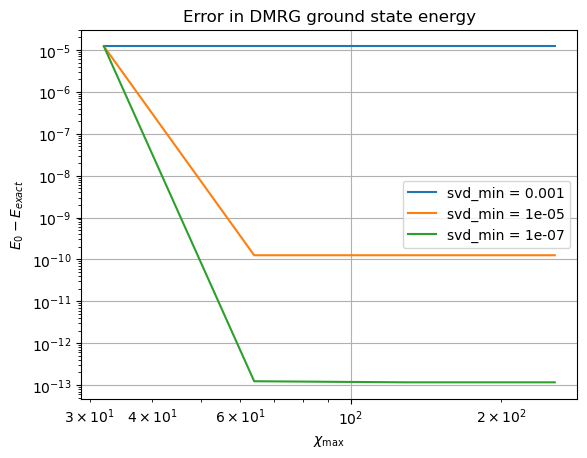

In [94]:
for i in range(len(svd_min_list)):
    plt.plot(chi_max_list, np.real(np.array(E0_list_list[i])-E0_exact), label="svd_min = "+str(svd_min_list[i]))
#end
plt.title("Error in DMRG ground state energy")
plt.xlabel("$\chi_\max$")
plt.ylabel("$E_0 - E_{exact}$")
plt.xscale('log')
plt.yscale('log')
ax.set_xticks(chi_max_list)
plt.legend()
plt.grid()

The accuracy improves when $\chi_{\max}$ increases at saturates at a value specified by the SVD cut-off. This demonstrates that the DMRG implementation works well and guides our choice of the DMRG parameters.

### Question 3 Preamble: Charge gap $\Delta_c = E(N{+}1) + E(N{-}1) - 2E(N)$ at $N = L$

Bethe ansatz at half filling [E. H. Lieb and F. Y. Wu, *Phys. Rev. Lett.* **20**, 1445 (1968)] tells us that the ground state energy and the charge gap take the following values

$$
\frac{E_0}{L} = -4t\int_0^\infty \frac{J_0(\omega)\,J_1(\omega)}{\omega\left[1 + e^{\,\omega U/2t}\right]}\,d\omega,
\qquad
\Delta_c = \frac{16\,t^2}{U}\int_1^\infty \frac{\sqrt{y^2-1}}{\sinh\!\left(2\pi t y/U\right)}\,dy .
$$

$\Delta_c > 0$ for every $U > 0$: the half-filled chain is a Mott insulator at arbitrarily weak repulsion. $\Delta_c \to U - 4t$ as $U \to \infty$. 

The cell below shows an example evaluation of the charge gap. Understand what lines 4 and 5 below, defining `plus` and `minus`, do.

In [99]:
from scipy.integrate import quad

U = 16.0
plus = list(half_filling);  plus[L // 2] = 'full'      # N = L+1 ----> add an electron at site L/2
minus = list(half_filling); minus[L // 2] = 'empty'    # N = L-1 ----> remove the electron at site L/2

E_0, _ = hubbard_gs(L, U, half_filling, t)
E_p, _ = hubbard_gs(L, U, plus, t)
E_m, _ = hubbard_gs(L, U, minus, t)
gap = E_p + E_m - 2 * E_0

# Lieb-Wu charge gap in the thermodynamic limit
a = 2 * np.pi * t / U                                  # 1/sinh(x), overflow-free
integrand = lambda y: np.sqrt(y*y - 1.) * 2*np.exp(-a*y) / (1. - np.exp(-2*a*y))
lieb_wu = (16 * t**2 / U) * quad(integrand, 1, np.inf, limit=200)[0]

print(f"E(N={L-1}) = {E_m:.6f}    E(N={L}) = {E_0:.6f}    E(N={L+1}) = {E_p:.6f}")
print(f"\ncharge gap   Delta_c = E(N+1) + E(N-1) - 2E(N) = {gap:.6f}   at L = {L}, U/t = {U:.0f}")
print(f"Lieb-Wu      Delta_c(L -> infinity)             = {lieb_wu:.6f}")

E(N=15) = -4.394543    E(N=16) = -2.625814    E(N=17) = 11.605457

charge gap   Delta_c = E(N+1) + E(N-1) - 2E(N) = 12.462542   at L = 16, U/t = 16
Lieb-Wu      Delta_c(L -> infinity)             = 12.344827


### Question 3
Plot the charge gap as a function of $U/t$, for $L=4,8,16$ and compare to the Lieb-Wu value and its atomic limit.

In [111]:
# your implementation goes here
Ls = [4, 8, 16]
Us = np.array([4, 8, 16, 32, 64])

dmrg_params = {'mixer': True, 'combine': True, 'max_E_err': 1.e-10,
               'trunc_params': {'chi_max': 50, 'svd_min': 1.e-7}}

gap_list = []
for L in Ls :
    half_filling = ['up', 'down'] * (L // 2)          # N = L, S^z_tot = 0
    gaps = []

    for U in Us:
        print("U = ", U)
        t = 1.0
        plus = list(half_filling);  plus[L // 2] = 'full'      # N = L+1 ----> add an electron at site L/2
        minus = list(half_filling); minus[L // 2] = 'empty'    # N = L-1 ----> remove the electron at site L/2

        E_0, _ = hubbard_gs(L, U, half_filling, t)
        E_p, _ = hubbard_gs(L, U, plus, t)
        E_m, _ = hubbard_gs(L, U, minus, t)

        gap = E_p + E_m - 2 * E_0
        gaps.append(gap)
    #end
    gap_list.append(gaps)
#end


# Lieb-Wu charge gap in the thermodynamic limit
U_list = np.linspace(np.min(Us), np.max(Us), 30)
Lieb_Wu_list = []
for U in U_list :
    a = 2 * np.pi * t / U                                  # 1/sinh(x), overflow-free
    integrand = lambda y: np.sqrt(y*y - 1.) * 2*np.exp(-a*y) / (1. - np.exp(-2*a*y))
    lieb_wu = (16 * t**2 / U) * quad(integrand, 1, np.inf, limit=200)[0]
    Lieb_Wu_list.append(lieb_wu)
#end
clear_output()

Text(0, 0.5, '$\\Delta_c$')

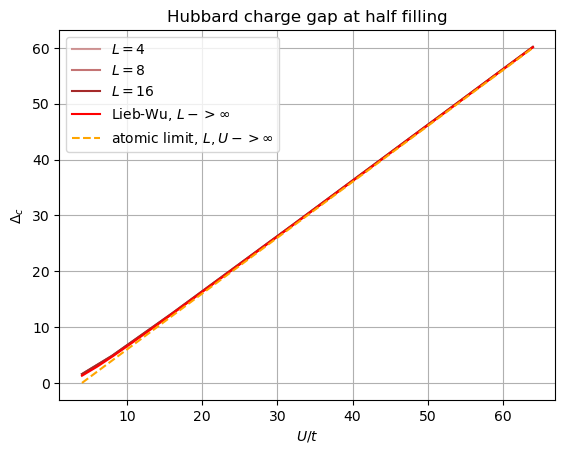

In [103]:
for i in range(len(Ls)) :
    plt.plot(Us, gap_list[i], label="$L = $"+str(L), color="brown", alpha=0.3+0.7*L[i]/16)
#end
plt.plot(U_list, Lieb_Wu_list, label="Lieb-Wu, $L -> \infty$", color="red")
plt.plot(Us, Us-4*t, label="atomic limit, $L,U -> \infty$", ls="--", color="orange")
plt.title("Hubbard charge gap at half filling")
plt.legend()
plt.grid()
plt.xlabel("$U/t$")
plt.ylabel("$\Delta_c$")

$\Delta_c$ follows a strong linear trend. To see things better, we can subtract the linear part.

Text(0, 0.5, '$\\Delta_c - (4U-t)$')

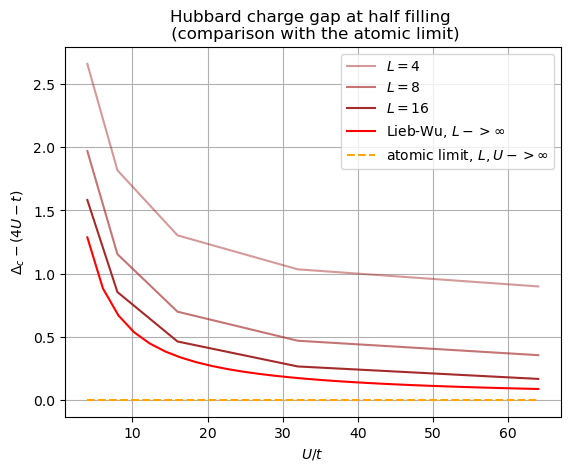

In [116]:
for i in range(len(Ls)) :
    plt.plot(Us, np.array(gap_list[i]) - (Us-4*t), label="$L = $"+str(Ls[i]), color="brown", alpha=0.3+0.7*Ls[i]/16)
#end
plt.plot(U_list, np.array(Lieb_Wu_list)-(U_list-4*t) , label="Lieb-Wu, $L -> \infty$", color="red")
plt.plot(Us, 0*np.array(Us), label="atomic limit, $L,U -> \infty$", ls="--", color="orange")
plt.title("Hubbard charge gap at half filling \n (comparison with the atomic limit)")
plt.legend()
plt.grid()
plt.xlabel("$U/t$")
plt.ylabel("$\Delta_c - (4U-t)$")

Now, all is clear. The brown curves for finite $L$ approach the Lieb-Wu limit (in red) as $L \to \infty$. This in turn converges to the atomic limit when $U \to \infty$.

### Question 4: Plot the double occupancy $\langle D\rangle/L = \frac{1}{L} \sum_i \langle n_{i,\uparrow} n_{i,\downarrow}\rangle$
You may use the following code example to figure out how to extract the double occupancy (of course you are free to adjust the parameters that you pass to `hubbard_gs`)
```python
    hubbard_gs(L, U, ['up', 'down'] * (L // 2), t, chi_max=100)[1].expectation_value('NuNd')
```

In [141]:
# your implementation here
t = 1
Ls = [4, 8, 12, 16]
U_progression = np.array([0.5, 1, 2, 4, 8, 16])

U_list = []
D_list = []
num_Ls = len(Ls)
for i in range(num_Ls):
    L = Ls[i]
    Us = 2**(i/num_Ls) * U_progression

    Ds = []
    for U in Us :
        print("U = ", U)
        D = 1/L*np.sum(hubbard_gs(L, U, ['up', 'down'] * (L // 2), t, chi_max=100)[1].expectation_value('NuNd'))
        Ds.append(D)
    #end
    U_list.append(Us)
    D_list.append(Ds)
#end
clear_output()

As $U \to \infty$, the double occupancy should go to zero. Since this can be viewed intuitively as an order parameter for a phase transition, we expect some critical exponent. However, the current implementation forces us to work with open boundary conditions and small systems ($L < 200$), so we are in a dire need to understand finite size effects.

Text(0, 0.5, ' < D >  / L')

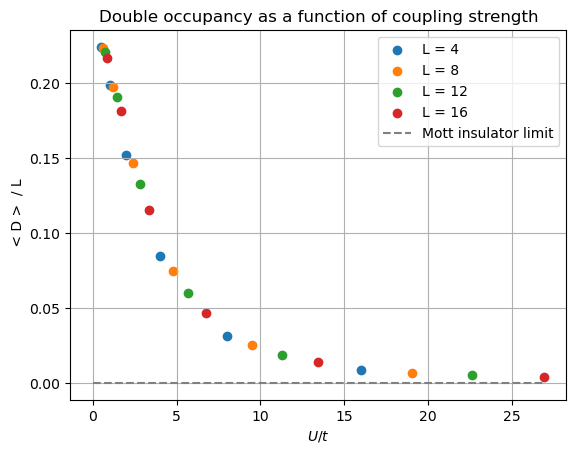

In [142]:
for i in range(num_Ls):
    L = Ls[i]
    Us = U_list[i]
    Ds = D_list[i]
    plt.scatter(Us,Ds, label = "L = "+str(L))
#end
plt.grid()
plt.plot([0,np.max(U_list)], [0,0], label="Mott insulator limit", color = "gray", ls="--")
plt.legend()
plt.title("Double occupancy as a function of coupling strength")
plt.xlabel("$U/t$")
plt.ylabel(" < D >  / L")

Double occupancy goes to 0 in the $U \to \infty$ limit, as expected for the Mott insulator phase. The finite size effects are small and the current progression of $L$ allows us to conclude about the thermodynamic limit. Basing on a log-log plot, we can conclude the existence of a power law behaviour in the large $U$ limit. The critical exponent could be extracted from the linear part of the graph. In practice, it should be of more research value than any particular $D(U)$ point.

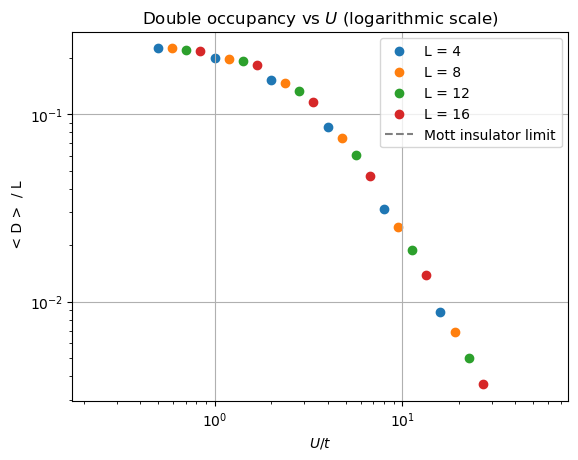

In [148]:
plt.plot()
plt.axis('equal')
for i in range(num_Ls):
    L = Ls[i]
    Us = U_list[i]
    Ds = D_list[i]
    plt.scatter(Us,Ds, label = "L = "+str(L))
#end
plt.grid()
plt.plot([0,np.max(U_list)], [0,0], label="Mott insulator limit", color = "gray", ls="--")
plt.legend()
plt.title("Double occupancy vs $U$ (logarithmic scale)")
plt.xlabel("$U/t$")
plt.ylabel(" < D >  / L")
plt.xscale('log')
plt.yscale('log')

### Question 5: Entanglement entropy
Plot $S(\ell)$ for versus the bond $\ell$, with the convention that bond $\ell$ is delimited by sites $\ell,\ell+1$, and fit the Calabrese-Cardy form to extract $c$ by fitting in two limits U/t=16, and U/t=0. Careful with odd sites versus even sites, the values of $c$ differ. Play $\chi$ and chain length $L$ to capture the finite size effect.

Again, you may use the following code snippet to figure out how to extract the entanglement entropies along the chain (of course you are free to adjust the parameters you pass to `hubbard_gs`). 
```python
    _, psi_S = hubbard_gs(L, U, half_filling, t, chi_max=100)
    S_hub = psi_S.entanglement_entropy()
```


$$S(\ell) = \frac{c}{6}\,\ln\!\left[\frac{2L}{\pi}\sin\frac{\pi\ell}{L}\right] + s_1,$$


c =  2.362220109728874


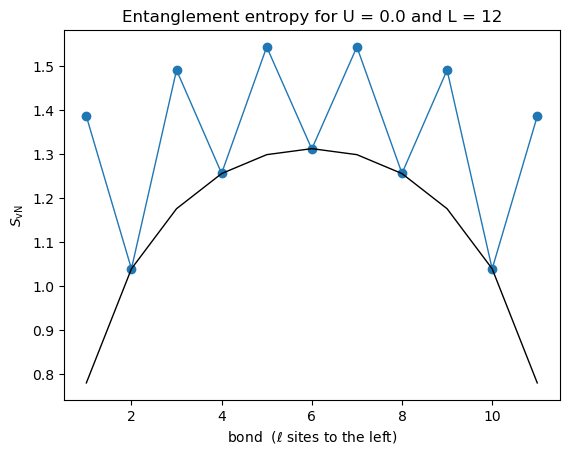

In [55]:
# your implementation here

def fit_Calabrese_Cardy(U=U,L=L, chi_max=100, bonds_parity = 0, plot=True) :
    half_filling = ['up', 'down'] * (L // 2)
    _, psi = hubbard_gs(L, U, half_filling, t, chi_max=chi_max)
    S_vN = psi.entanglement_entropy()
    bonds = np.arange(1, L)

    # Calabrese-Cardy, open chain:  S(l) = (c/6) ln[(2L/pi) sin(pi l/L)] + s1.
    # Fit the even-l branch only: an odd block leaves an unpaired spin and sits on its own branch.
    x = (2 * L / np.pi) * np.sin(np.pi * bonds / L)            # conformal chord length
    even = bonds % 2 == bonds_parity%2
    A = np.vstack([np.log(x[even]), np.ones(even.sum())]).T
    (slope, s1), *_ = np.linalg.lstsq(A, S_vN[even], rcond=None)
    c = 6 * slope
    if plot:
        #fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.2))

        plt.plot(bonds, S_vN, 'o-', lw=1)
        plt.plot(bonds, (c / 6) * np.log(x) + s1, '-', color='k', lw=1)
        plt.xlabel(r"bond  ($\ell$ sites to the left)")
        plt.ylabel(r"$S_{\mathrm{vN}}$")
        plt.title("Entanglement entropy for U = "+str(U)+" and L = "+str(L))
        print("c = ", c)
        #ax2.plot(np.log(x[even]), S_vN[even], 'o', label=r"even $\ell$  (fitted)")
        #ax2.plot(np.log(x[~even]), S_vN[~even], 's', mfc='none', label=r"odd $\ell$")
        #ax2.plot(np.log(x), (c / 6) * np.log(x) + s1, '-', color='k', lw=1,
        #        label=rf"slope $c/6$,  $c = {c:.3f}$,  $s_1 = {s1:.3f}$")
        #ax2.set_xlabel(r"$\ln\,[(2L/\pi)\,\sin(\pi\ell/L)]$")
        #ax2.set_ylabel(r"$S_{\mathrm{vN}}$")
        #ax2.legend()
        #fig.tight_layout()
    #end
    return S_vN, c, s1
#end

U = 0.0; L = 12
S_vn, c, s1 = fit_Calabrese_Cardy(U=U,L=L)

c =  1.0929688632498622


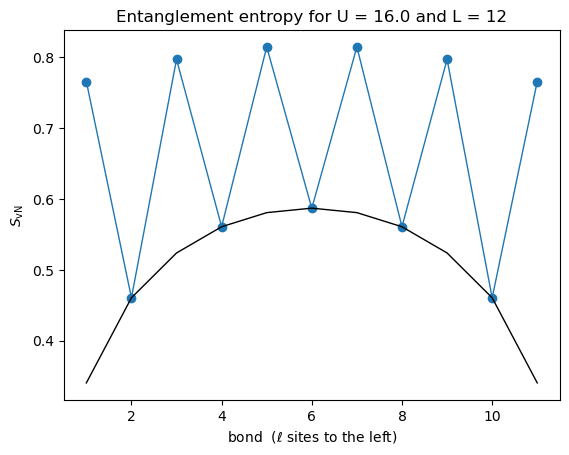

In [56]:
U = 16.0; L = 12
S_vn, c, s1 = fit_Calabrese_Cardy(U=U,L=L)

In [ ]:
U = 0.0;
Ls = [8, 16, 24, 32, 40]
c_list = []
for L in Ls:
    print(L)
    S_vn, c, s1 = fit_Calabrese_Cardy(U=U,L=L,chi_max=100,plot=False)
    c_list.append(c)
#end
clear_output()

Text(0.5, 1.0, 'Finite size effect in $c$')

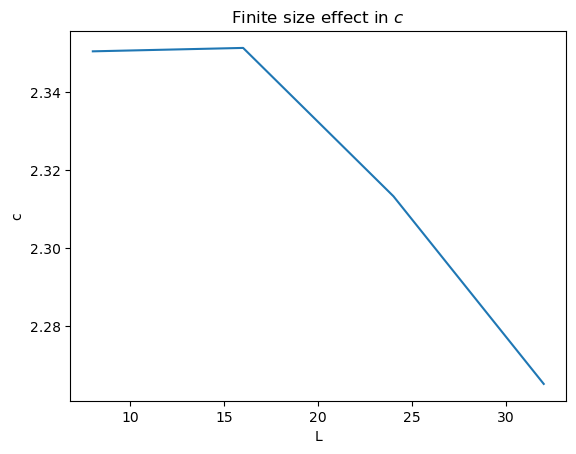

In [87]:
plt.plot(Ls, c_list)
plt.xlabel("L")
plt.ylabel("c")
plt.title("Finite size effect in $c$")

Sadly, I find it difficult to explore higher $L$, which is problematic because, clearly, the value of $c$ has not settled. I can guess that $c \to 2$ when $L \to \infty$.

In [88]:
U = 16.0;
Ls = [8, 16, 24, 32, 40]
c_list = []
for L in Ls:
    print(L)
    S_vn, c, s1 = fit_Calabrese_Cardy(U=U,L=L,chi_max=100,plot=False)
    c_list.append(c)
#end
clear_output()

Text(0.5, 1.0, 'Finite size effect in $c$ (strong coupling)')

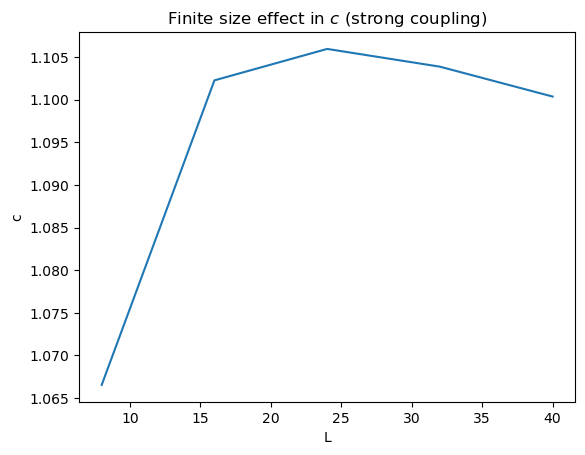

In [89]:
plt.plot(Ls, c_list)
plt.xlabel("L")
plt.ylabel("c")
plt.title("Finite size effect in $c$ (strong coupling)")

A similar problem persists. Here, I can guess that $c=1$ but numerics does not let me conclude that. As shown before, the bond dimension is not the culprit. Its influence on $c$ is much smaller that that of $L$, and at $\chi = 100$, it is already saturated.

Text(0.5, 1.0, 'Effects of the bond dimension on the $c$ estimate')

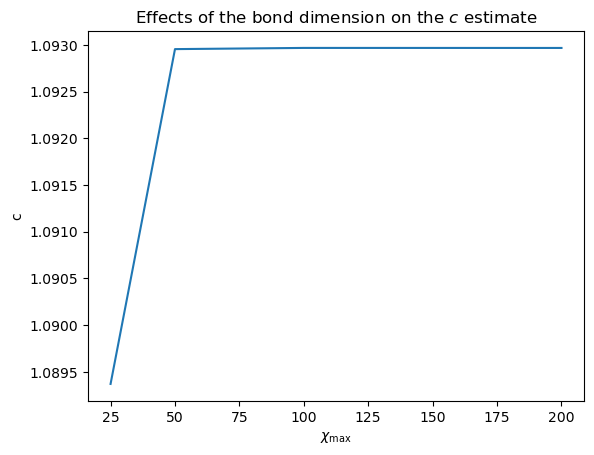

In [92]:
U = 16.0;
L = 12
chi_max_list = [25, 50, 100, 200]
c_list = []
for chi_max in chi_max_list:
    print(L)
    S_vn, c, s1 = fit_Calabrese_Cardy(U=U,L=L,chi_max=chi_max,plot=False)
    c_list.append(c)
#end
clear_output()

plt.plot(chi_max_list, c_list)
plt.xlabel("$\chi_{\max}$")
plt.ylabel("c")
plt.title("Effects of the bond dimension on the $c$ estimate")


To draw sound physical conclusions, I would need to explore higher $L$ which is not possible with the current implementation on my machine.

## Bonus question 

You have found a charge gap. Calculate the spin gap i.e. the energy cost of flipping a single spin. How does it scale with L? (should be 1/L)

In [74]:
Ls = [4, 8, 16]
U_progression = np.array([2, 4, 8, 16, 32])

dmrg_params = {'mixer': True, 'combine': True, 'max_E_err': 1.e-10,
               'trunc_params': {'chi_max': 50, 'svd_min': 1.e-7}}

U_list = []
gap_list = []
num_Ls = len(Ls)
for L in Ls :
    Us = 2**(i/num_Ls) * U_progression
    half_filling = ['up', 'down'] * (L // 2)          # N = L, S^z_tot = 0
    gaps = []

    for U in Us:
        print("U = ", U)
        t = 1.0
        plus = list(half_filling);  plus[0] = 'down'      # flip a single spin

        E_0, _ = hubbard_gs(L, U, half_filling, t)
        E_p, _ = hubbard_gs(L, U, plus, t)

        gap = E_p - E_0
        gaps.append(gap)
    #end
    gap_list.append(gaps)
    U_list.append(Us)
#end
clear_output()

Text(0, 0.5, '$\\Delta_s$')

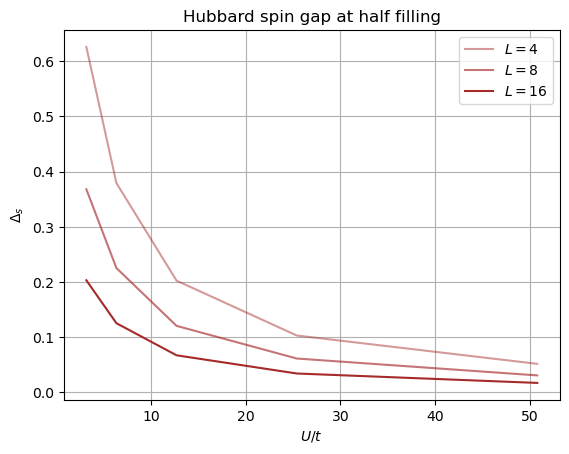

In [76]:
for i in range(len(Ls)) :
    plt.plot(U_list[i], gap_list[i], label="$L = $"+str(Ls[i]), color="brown", alpha=0.3+0.7*Ls[i]/16)
#end
plt.title("Hubbard spin gap at half filling")
plt.legend()
plt.grid()
plt.xlabel("$U/t$")
plt.ylabel("$\Delta_s$")

(np.float64(2.7638257599355525),
 np.float64(58.35023926772589),
 np.float64(0.014404332915968326),
 np.float64(0.749159031673311))

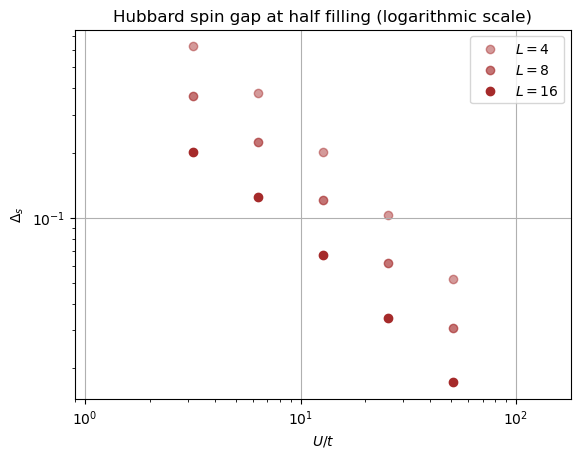

In [80]:
for i in range(len(Ls)) :
    plt.scatter(U_list[i], gap_list[i], label="$L = $"+str(Ls[i]), color="brown", alpha=0.3+0.7*Ls[i]/16)
#end
plt.title("Hubbard spin gap at half filling (logarithmic scale)")
plt.legend()
plt.grid()
plt.xlabel("$U/t$")
plt.ylabel("$\Delta_s$")
plt.xscale('log')
plt.yscale('log')
plt.axis('equal')

This suggests the scaling $\Delta_s \propto L^{-1} (U/t)^{-1}$. Contrary to the charge gap, the spin gap disappears in the strong coupling limit.